# Telco Customer Churn — Exploratory Data Analysis
**Goal:** Understand the dataset structure, data quality, and key patterns before modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 1. Dataset Overview

In [2]:
print('Shape:', df.shape)
print(f'\n{df.shape[0]} customers, {df.shape[1]} features')

Shape: (7043, 21)

7043 customers, 21 features


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Cleaning

In [6]:
# TotalCharges is stored as string — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0])

Missing values:
TotalCharges    11
dtype: int64


In [7]:
# All 11 nulls in TotalCharges have tenure=0 (new customers, never billed)
# Drop these rows — they are not useful for churn analysis
df = df[df['TotalCharges'].notnull()].reset_index(drop=True)
print('Rows after dropping nulls:', len(df))

Rows after dropping nulls: 7032


In [8]:
# Drop customerID — not a feature
df.drop(columns=['customerID'], inplace=True)

# Convert SeniorCitizen from 0/1 to Yes/No for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print('Cleaning complete.')
print('Final shape:', df.shape)

Cleaning complete.
Final shape: (7032, 20)


## 3. Churn Distribution

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


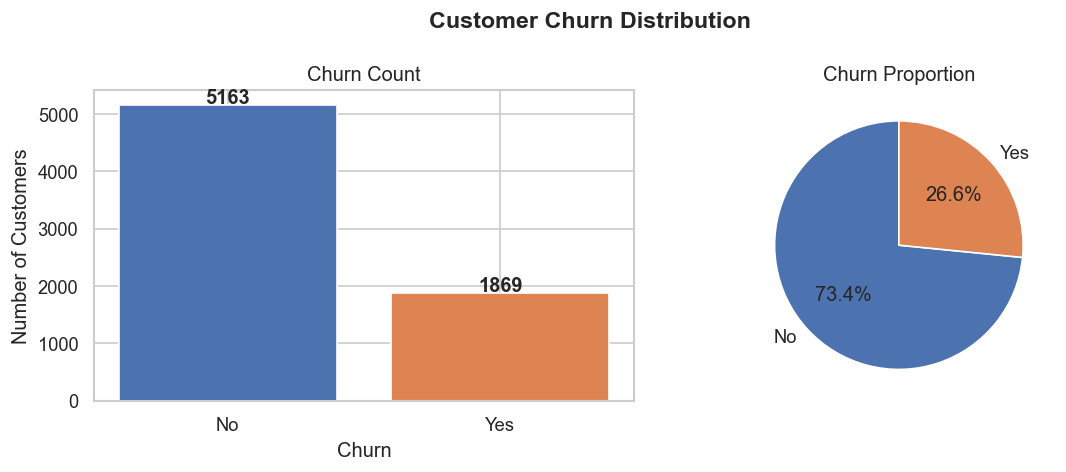

In [9]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2)

print('Churn counts:')
print(churn_counts)
print('\nChurn percentage:')
print(churn_pct)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.suptitle('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_churn_distribution.png', bbox_inches='tight')
plt.show()

## 4. Demographics Analysis

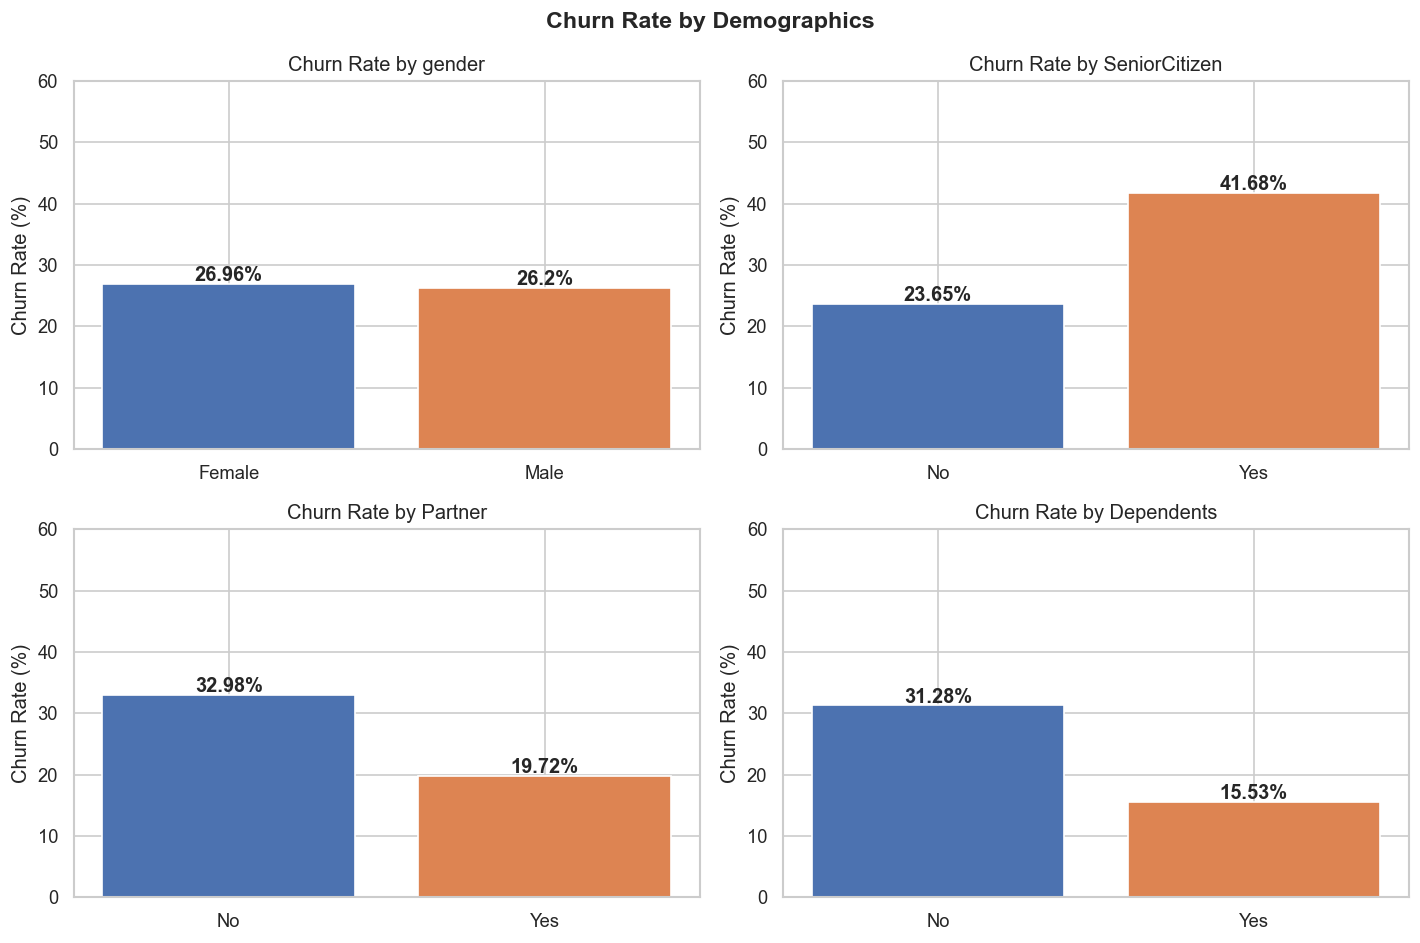

In [10]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(2)
    axes[i].bar(churn_rate.index, churn_rate.values, color=['#4C72B0', '#DD8452'])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.suptitle('Churn Rate by Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_churn_by_demographics.png', bbox_inches='tight')
plt.show()

## 5. Contract & Service Analysis

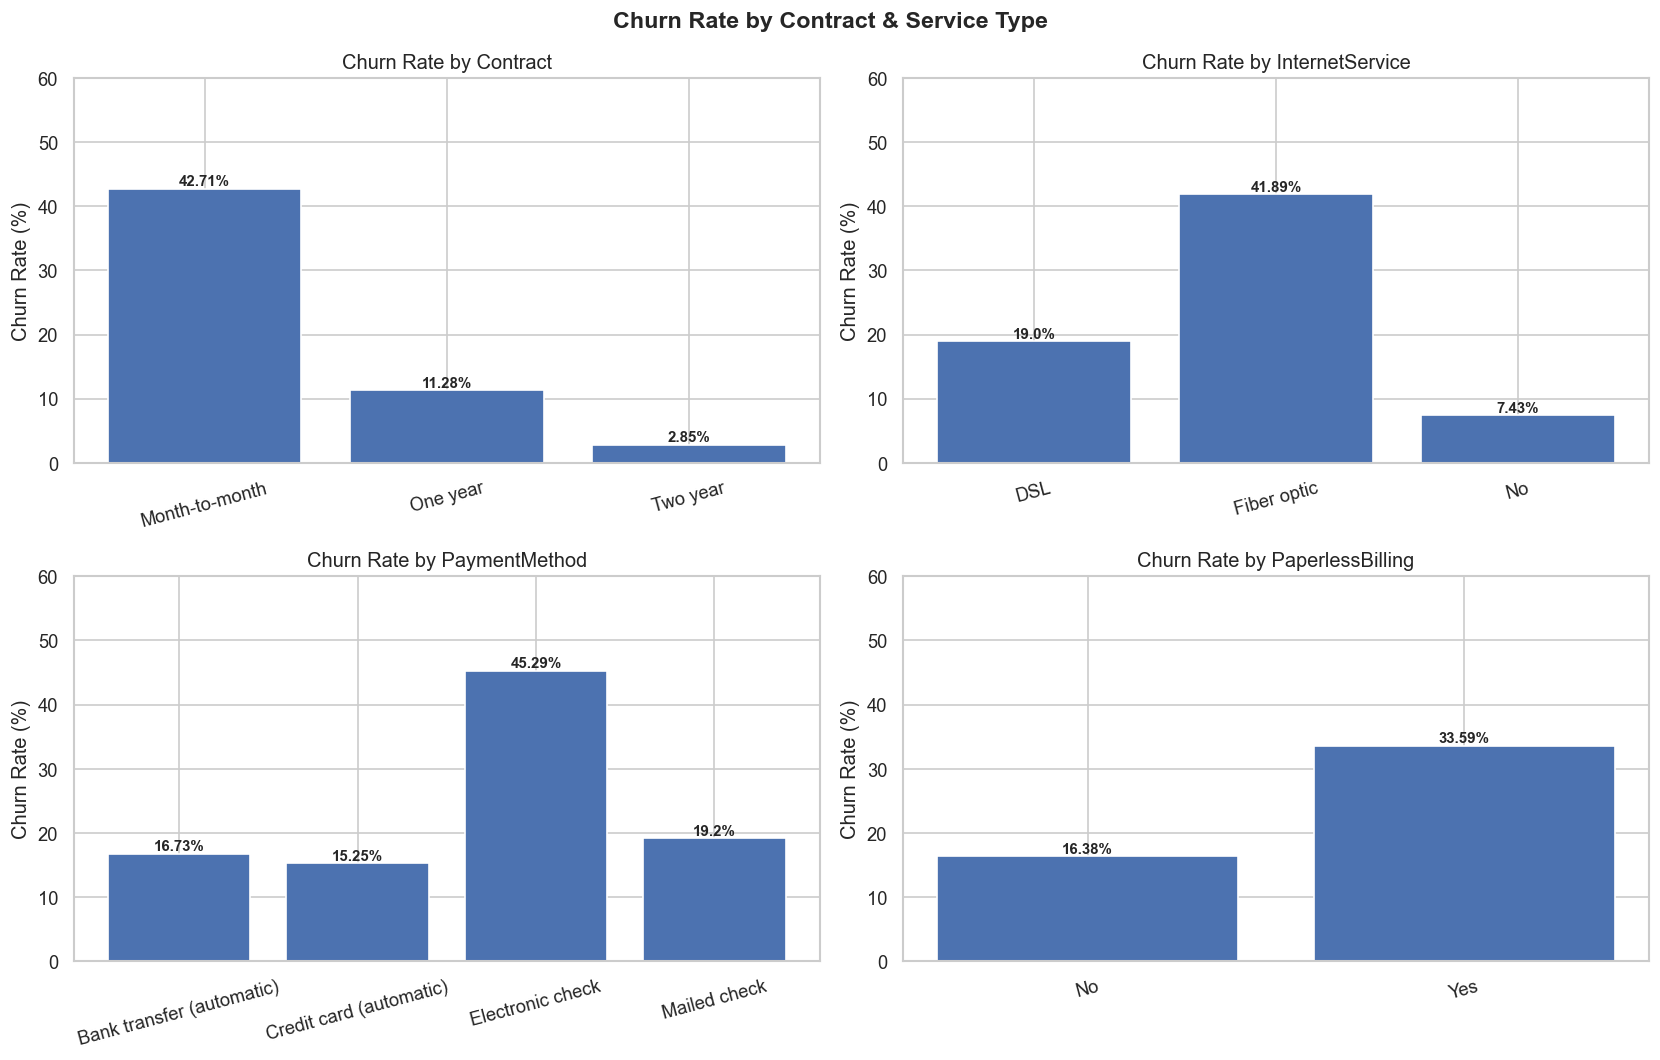

In [11]:
service_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(2)
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color='#4C72B0')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.5, f'{v}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Churn Rate by Contract & Service Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_churn_by_service.png', bbox_inches='tight')
plt.show()

## 6. Numerical Features Distribution

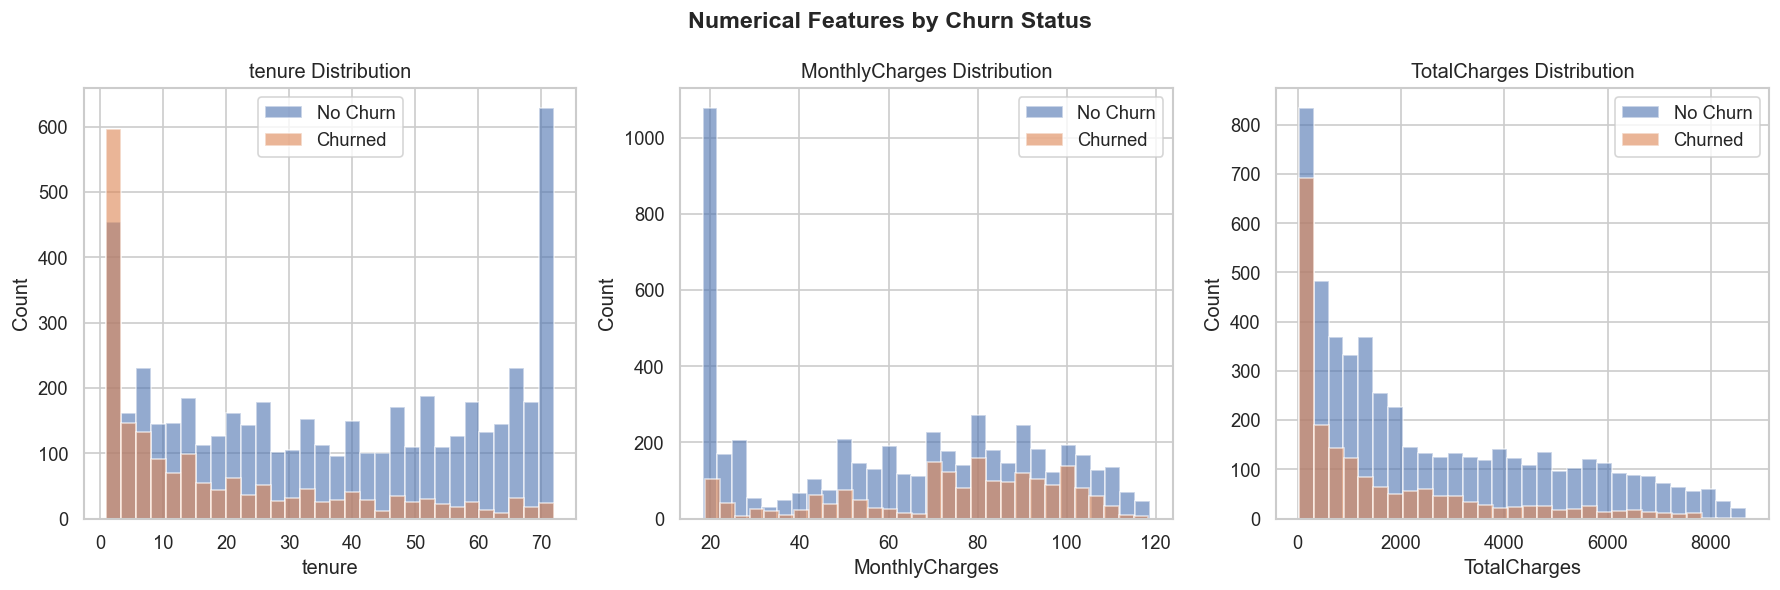

In [12]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    churned = df[df['Churn'] == 'Yes'][col]
    not_churned = df[df['Churn'] == 'No'][col]
    axes[i].hist(not_churned, bins=30, alpha=0.6, label='No Churn', color='#4C72B0')
    axes[i].hist(churned, bins=30, alpha=0.6, label='Churned', color='#DD8452')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Numerical Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_numerical_distributions.png', bbox_inches='tight')
plt.show()

## 7. Correlation Heatmap (Numerical Features)

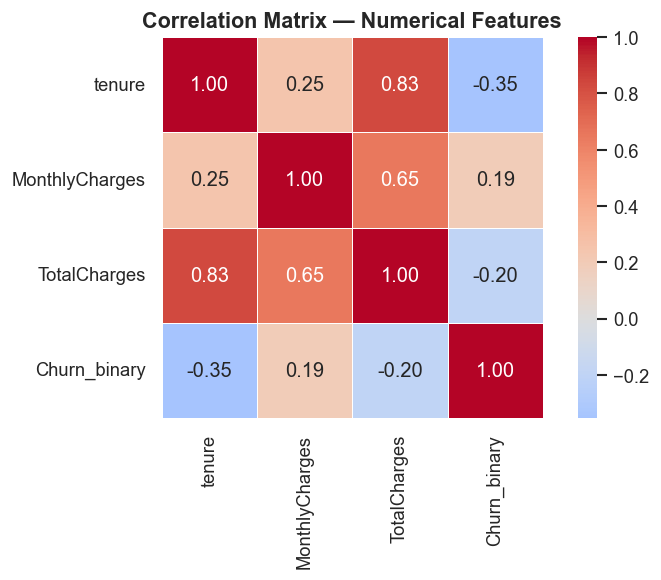

In [13]:
df_encoded = df.copy()
df_encoded['Churn_binary'] = (df_encoded['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr = df_encoded[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Key Findings Summary

In [14]:
print('=== KEY FINDINGS ===')
print(f'Total customers: {len(df)}')
print(f'Churn rate: {(df["Churn"]=="Yes").mean()*100:.1f}%')
print()

print('--- Contract Type ---')
print(df.groupby('Contract')['Churn'].apply(lambda x: f'{(x=="Yes").mean()*100:.1f}% churn'))
print()

print('--- Senior Citizens ---')
print(df.groupby('SeniorCitizen')['Churn'].apply(lambda x: f'{(x=="Yes").mean()*100:.1f}% churn'))
print()

print('--- Avg Tenure (months) ---')
print(df.groupby('Churn')['tenure'].mean().round(1))
print()

print('--- Avg Monthly Charges ---')
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

=== KEY FINDINGS ===
Total customers: 7032
Churn rate: 26.6%

--- Contract Type ---
Contract
Month-to-month    42.7% churn
One year          11.3% churn
Two year           2.8% churn
Name: Churn, dtype: str

--- Senior Citizens ---
SeniorCitizen
No     23.7% churn
Yes    41.7% churn
Name: Churn, dtype: str

--- Avg Tenure (months) ---
Churn
No     37.7
Yes    18.0
Name: tenure, dtype: float64

--- Avg Monthly Charges ---
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64
